# Vehicle Systems Demonstration

The Systems model incorporates:

Functional block diagrams: Represented by the FunctionalBlock class and included in SystemAttributes.
Data signals: Described by the DataSignal class, including signal type, direction, source, and destination.
Physical characteristics: Expanded in the PhysicalCharacteristics class to include weight, dimensions, volume, and center of gravity.
Cooling requirements: Added as CoolingRequirements class.
Power requirements: Expanded in the PowerRequirements class to include more detailed information.

This model aligns with several military standards:

* MIL-STD-881F: Used for the WBS structure.
* MIL-STD-704F: Reflected in the power requirements specifications.
* MIL-STD-810G: Considerations for environmental conditions (like temperature) in cooling requirements.
* MIL-HDBK-516C: Airworthiness certification criteria, which informs the overall system design.


In [37]:
#%%writefile "Vehicle_Systems.py"
"""
Vehicle Systems module for aircraft system modeling.

This module provides Pydantic models for representing various aspects of aircraft systems,
including functional blocks, data signals, physical characteristics, and system attributes.
"""

from pydantic import BaseModel, Field, field_validator
from typing import List, Dict, Optional, Literal, Tuple
from enum import Enum


class SignalType(str, Enum):
    """Enumeration of signal types."""

    ANALOG = "Analog"
    DIGITAL = "Digital"
    DISCRETE = "Discrete"
    SERIAL = "Serial"


class SignalDirection(str, Enum):
    """Enumeration of signal directions."""

    INPUT = "Input"
    OUTPUT = "Output"
    BIDIRECTIONAL = "Bidirectional"


class FunctionalBlock(BaseModel):
    """
    Represents a functional block in the system diagram.

    Attributes:
        block_id (str): Unique identifier for the block.
        name (str): Name of the functional block.
        description (str): Brief description of the block's function.
        inputs (List[str]): List of input signal names.
        outputs (List[str]): List of output signal names.
    """

    block_id: str = Field(..., min_length=1, max_length=50)
    name: str = Field(..., min_length=1, max_length=100)
    description: str = Field(..., min_length=1, max_length=500)
    inputs: List[str] = Field(default_factory=list)
    outputs: List[str] = Field(default_factory=list)


class DataSignal(BaseModel):
    """
    Represents a data signal in the system.

    Attributes:
        name (str): Name of the signal.
        type (SignalType): Type of the signal.
        direction (SignalDirection): Direction of the signal.
        source (str): Source of the signal (system or component ID).
        destination (str): Destination of the signal (system or component ID).
        description (str): Brief description of the signal.
    """

    name: str = Field(..., min_length=1, max_length=100)
    type: SignalType
    direction: SignalDirection
    source: str = Field(..., min_length=1, max_length=50)
    destination: str = Field(..., min_length=1, max_length=50)
    description: str = Field(..., min_length=1, max_length=500)


class PhysicalCharacteristics(BaseModel):
    """
    Physical characteristics of the system.

    Attributes:
        weight (float): Weight in kilograms.
        dimensions (Dict[str, float]): Dimensions in meters (length, width, height).
        volume (float): Volume in cubic meters.
        center_of_gravity (Dict[str, float]): Center of gravity coordinates (x, y, z) in meters.
    """

    weight: float = Field(..., gt=0)
    dimensions: Dict[str, float] = Field(..., min_items=3, max_items=3)
    volume: float = Field(..., gt=0)
    center_of_gravity: Dict[str, float] = Field(..., min_items=3, max_items=3)

    @field_validator("dimensions")
    @classmethod
    def validate_dimensions(cls, v: Dict[str, float]) -> Dict[str, float]:
        """Validate that dimensions include length, width, and height."""
        if set(v.keys()) != {"length", "width", "height"}:
            raise ValueError("Dimensions must include 'length', 'width', and 'height'")
        return v

    @field_validator("center_of_gravity")
    @classmethod
    def validate_cog(cls, v: Dict[str, float]) -> Dict[str, float]:
        """Validate that center of gravity includes x, y, and z coordinates."""
        if set(v.keys()) != {"x", "y", "z"}:
            raise ValueError("Center of gravity must include 'x', 'y', and 'z' coordinates")
        return v


class FluidFlowCharacteristics(BaseModel):
    """
    Represents the flow characteristics of a working fluid in the system.

    Attributes:
        fluid_type (str): Type of fluid (e.g., "Hydraulic Oil", "Fuel", "Coolant").
        flow_rate (float): Nominal flow rate in liters per minute.
        max_pressure (float): Maximum operating pressure in pascals.
        min_pressure (float): Minimum operating pressure in pascals.
        temperature_range (Tuple[float, float]): Operating temperature range in Celsius (min, max).
        viscosity (float): Kinematic viscosity in centistokes at operating temperature.
        density (float): Fluid density in kg/m³ at operating temperature.
    """

    fluid_type: str = Field(..., min_length=1, max_length=50)
    flow_rate: float = Field(..., gt=0)
    max_pressure: float = Field(..., gt=0)
    min_pressure: float = Field(..., ge=0)
    temperature_range: Tuple[float, float] = Field(..., min_items=2, max_items=2)
    viscosity: float = Field(..., gt=0)
    density: float = Field(..., gt=0)

    @field_validator("temperature_range")
    @classmethod
    def validate_temperature_range(cls, v: Tuple[float, float]) -> Tuple[float, float]:
        """Validate that the minimum temperature is less than the maximum temperature."""
        if v[0] >= v[1]:
            raise ValueError("Minimum temperature must be less than maximum temperature")
        return v


class CoolingRequirements(BaseModel):
    """
    Cooling requirements for the system.

    Attributes:
        method (str): Cooling method (e.g., "Air", "Liquid", "Conduction").
        heat_dissipation (float): Heat dissipation in watts.
        max_operating_temperature (float): Maximum operating temperature in Celsius.
    """

    method: str = Field(..., min_length=1, max_length=50)
    heat_dissipation: float = Field(..., ge=0)
    max_operating_temperature: float


class PowerRequirements(BaseModel):
    """
    Power requirements for the system.

    Attributes:
        voltage (float): Required voltage in volts.
        current (float): Required current in amperes.
        frequency (Optional[float]): Required frequency in Hz, if applicable.
        power_type (str): Type of power (e.g., "AC", "DC").
        peak_power (float): Peak power consumption in watts.
        average_power (float): Average power consumption in watts.
    """

    voltage: float = Field(..., gt=0)
    current: float = Field(..., gt=0)
    frequency: Optional[float] = Field(None, gt=0)
    power_type: str = Field(..., min_length=1, max_length=20)
    peak_power: float = Field(..., gt=0)
    average_power: float = Field(..., gt=0)


class SystemAttributes(BaseModel):
    """
    Attributes specific to an aircraft system.

    Attributes:
        functional_blocks (List[FunctionalBlock]): List of functional blocks in the system.
        data_signals (List[DataSignal]): List of data signals in the system.
        physical_characteristics (PhysicalCharacteristics): Physical characteristics of the system.
        cooling_requirements (CoolingRequirements): Cooling requirements for the system.
        power_requirements (PowerRequirements): Power requirements for the system.
        fluid_flow (Optional[FluidFlowCharacteristics]): Fluid flow characteristics, if applicable.
    """

    functional_blocks: List[FunctionalBlock]
    data_signals: List[DataSignal]
    physical_characteristics: PhysicalCharacteristics
    cooling_requirements: CoolingRequirements
    power_requirements: PowerRequirements
    fluid_flow: Optional[FluidFlowCharacteristics] = None


class System(BaseModel):
    """
    Represents an aircraft system.

    Attributes:
        wbs_id (str): Work Breakdown Structure ID.
        mil_std_881f_reference (str): Reference to MIL-STD-881F.
        name (str): Name of the system.
        type (Literal["System"]): Type of the item (always "System" for this class).
        attributes (SystemAttributes): Specific attributes of the system.
        components (List[str]): List of component WBS IDs that make up this system.
    """

    wbs_id: str = Field(..., min_length=1, max_length=20)
    mil_std_881f_reference: str = Field(..., min_length=1, max_length=20)
    name: str = Field(..., min_length=1, max_length=100)
    type: Literal["System"] = "System"
    attributes: SystemAttributes
    components: List[str] = Field(..., min_items=1)

    @field_validator("type")
    @classmethod
    def type_must_be_system(cls, v: str) -> str:
        """Validate that the type is always 'System'."""
        if v != "System":
            raise ValueError("Type must be 'System'")
        return v


class Systems(BaseModel):
    """
    A collection of aircraft systems.

    Attributes:
        systems (List[System]): List of aircraft systems.
    """

    systems: List[System] = Field(..., min_items=1)


Here's an example Python script that takes a `System` object and produces both a diagram and a table of attributes using the graphviz Python library:

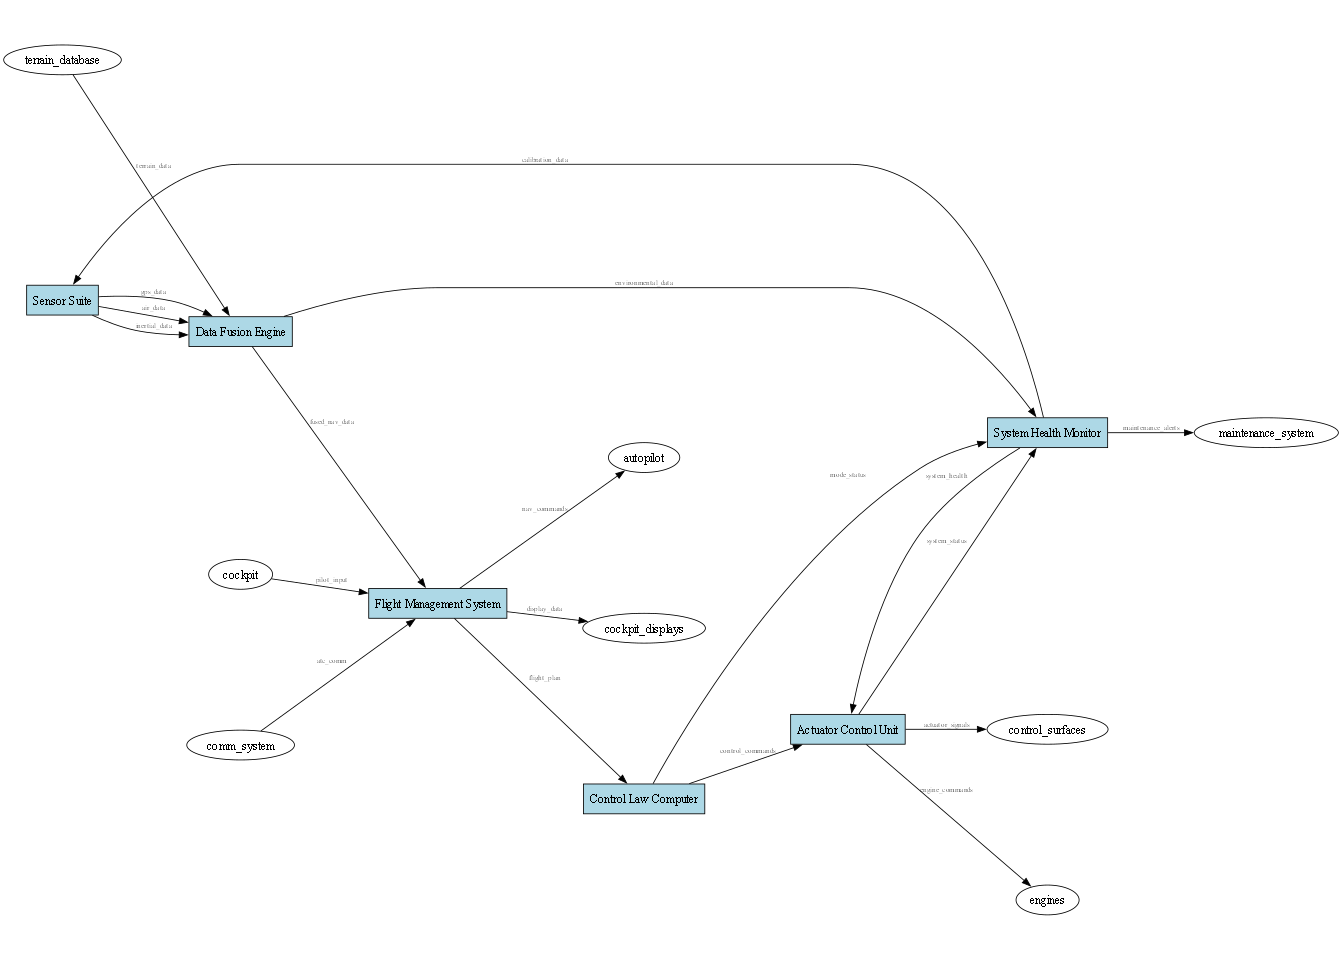

Weight,25.5 kg
Dimensions,0.8x0.6x0.4 m
Volume,0.192 m³
Center of Gravity,"(0.4, 0.3, 0.2)"
Method,Liquid
Heat Dissipation,500.0 W
Max Operating Temperature,95.0 °C
Voltage,28.0 V
Current,20.0 A
Frequency,400.0 Hz
Power Type,AC


In [38]:
import graphviz
from tabulate import tabulate
from IPython.display import display, Markdown, Image, HTML
from pydantic import BaseModel
from typing import List, Dict

# Import the necessary classes from your Vehicle_Systems file
from Vehicle_Systems import System, SystemAttributes, FunctionalBlock, DataSignal, SignalType, SignalDirection, PhysicalCharacteristics, CoolingRequirements, PowerRequirements

def create_system_diagram(system: System) -> graphviz.Digraph:
    dot = graphviz.Digraph(comment=f'Functional Block Diagram - {system.name}')
    dot.attr(rankdir='LR', size='14,10', ratio='fill')

    # Add nodes for each functional block
    for block in system.attributes.functional_blocks:
        dot.node(block.block_id, block.name, shape='box', style='filled', fillcolor='lightblue')

    # Add edges for data signals
    for signal in system.attributes.data_signals:
        dot.edge(signal.source, signal.destination, label=signal.name, fontsize='8', len='1.5')

    return dot

# The create_system_attribute_tables and display_system_info functions remain the same as in the previous example

# Create a more complex sample System object with multiple inputs/outputs between blocks
complex_system = System(
    wbs_id="1.1",
    mil_std_881f_reference="G.3.1",
    name="Advanced Integrated Avionics System",
    type="System",
    attributes=SystemAttributes(
        functional_blocks=[
            FunctionalBlock(block_id="FB1", name="Sensor Suite", description="Collects various flight data", 
                            inputs=["calibration_data"], 
                            outputs=["air_data", "inertial_data", "gps_data"]),
            FunctionalBlock(block_id="FB2", name="Data Fusion Engine", description="Combines and processes sensor data", 
                            inputs=["air_data", "inertial_data", "gps_data", "terrain_data"], 
                            outputs=["fused_nav_data", "environmental_data"]),
            FunctionalBlock(block_id="FB3", name="Flight Management System", description="Manages flight plan and navigation", 
                            inputs=["fused_nav_data", "pilot_input", "atc_comm"], 
                            outputs=["flight_plan", "nav_commands", "display_data"]),
            FunctionalBlock(block_id="FB4", name="Control Law Computer", description="Computes control commands", 
                            inputs=["fused_nav_data", "flight_plan", "pilot_input"], 
                            outputs=["control_commands", "mode_status"]),
            FunctionalBlock(block_id="FB5", name="Actuator Control Unit", description="Drives control surfaces and engines", 
                            inputs=["control_commands", "system_health"], 
                            outputs=["actuator_signals", "engine_commands", "system_status"]),
            FunctionalBlock(block_id="FB6", name="System Health Monitor", description="Monitors overall system health", 
                            inputs=["system_status", "environmental_data", "mode_status"], 
                            outputs=["system_health", "maintenance_alerts", "calibration_data"])
        ],
        data_signals=[
            DataSignal(name="air_data", type=SignalType.ANALOG, direction=SignalDirection.OUTPUT, source="FB1", destination="FB2", description="Air pressure and temperature data"),
            DataSignal(name="inertial_data", type=SignalType.DIGITAL, direction=SignalDirection.OUTPUT, source="FB1", destination="FB2", description="Acceleration and rotation data"),
            DataSignal(name="gps_data", type=SignalType.DIGITAL, direction=SignalDirection.OUTPUT, source="FB1", destination="FB2", description="GPS position and velocity"),
            DataSignal(name="terrain_data", type=SignalType.DIGITAL, direction=SignalDirection.INPUT, source="terrain_database", destination="FB2", description="Terrain elevation data"),
            DataSignal(name="fused_nav_data", type=SignalType.DIGITAL, direction=SignalDirection.OUTPUT, source="FB2", destination="FB3", description="Fused navigation solution"),
            DataSignal(name="environmental_data", type=SignalType.DIGITAL, direction=SignalDirection.OUTPUT, source="FB2", destination="FB6", description="Processed environmental data"),
            DataSignal(name="pilot_input", type=SignalType.DIGITAL, direction=SignalDirection.INPUT, source="cockpit", destination="FB3", description="Pilot control inputs"),
            DataSignal(name="atc_comm", type=SignalType.DIGITAL, direction=SignalDirection.INPUT, source="comm_system", destination="FB3", description="Air Traffic Control communications"),
            DataSignal(name="flight_plan", type=SignalType.DIGITAL, direction=SignalDirection.OUTPUT, source="FB3", destination="FB4", description="Computed flight plan"),
            DataSignal(name="nav_commands", type=SignalType.DIGITAL, direction=SignalDirection.OUTPUT, source="FB3", destination="autopilot", description="Navigation commands"),
            DataSignal(name="display_data", type=SignalType.DIGITAL, direction=SignalDirection.OUTPUT, source="FB3", destination="cockpit_displays", description="Data for cockpit displays"),
            DataSignal(name="control_commands", type=SignalType.DIGITAL, direction=SignalDirection.OUTPUT, source="FB4", destination="FB5", description="Computed control commands"),
            DataSignal(name="mode_status", type=SignalType.DIGITAL, direction=SignalDirection.OUTPUT, source="FB4", destination="FB6", description="Current control mode status"),
            DataSignal(name="actuator_signals", type=SignalType.ANALOG, direction=SignalDirection.OUTPUT, source="FB5", destination="control_surfaces", description="Signals to control surface actuators"),
            DataSignal(name="engine_commands", type=SignalType.DIGITAL, direction=SignalDirection.OUTPUT, source="FB5", destination="engines", description="Commands to engine control units"),
            DataSignal(name="system_status", type=SignalType.DIGITAL, direction=SignalDirection.OUTPUT, source="FB5", destination="FB6", description="Status of actuators and engines"),
            DataSignal(name="system_health", type=SignalType.DIGITAL, direction=SignalDirection.OUTPUT, source="FB6", destination="FB5", description="Overall system health status"),
            DataSignal(name="maintenance_alerts", type=SignalType.DIGITAL, direction=SignalDirection.OUTPUT, source="FB6", destination="maintenance_system", description="Alerts for maintenance"),
            DataSignal(name="calibration_data", type=SignalType.DIGITAL, direction=SignalDirection.OUTPUT, source="FB6", destination="FB1", description="Sensor calibration data")
        ],
        physical_characteristics=PhysicalCharacteristics(
            weight=25.5,
            dimensions={"length": 0.8, "width": 0.6, "height": 0.4},
            volume=0.192,
            center_of_gravity={"x": 0.4, "y": 0.3, "z": 0.2}
        ),
        cooling_requirements=CoolingRequirements(
            method="Liquid",
            heat_dissipation=500,
            max_operating_temperature=95
        ),
        power_requirements=PowerRequirements(
            voltage=28,
            current=20,
            frequency=400,
            power_type="AC",
            peak_power=700,
            average_power=560
        )
    ),
    components=["1.1.1", "1.1.2", "1.1.3", "1.1.4", "1.1.5", "1.1.6"]
)

# Display the system information
display_system_info(complex_system)

This script does the following:

1. Defines a `create_system_diagram` function that generates a functional block diagram using `graphviz`.
2. Defines a `create_system_attribute_table` function that creates a formatted table of system attributes using `tabulate`.
3. Includes a `main` function that creates a sample `System` object and demonstrates how to use the diagram and table functions.

To use this script:

1. Ensure you have all the necessary Pydantic models defined (you can copy them from the previous response).
2. Run the script. It will generate a PNG image of the system diagram and print the attribute tables to the console.

The script will create a file named `system_diagram.png` in the same directory, showing the functional blocks and data signals. It will also print tables of the system's physical characteristics, cooling requirements, and power requirements to the console.

This approach provides a visual representation of the system's functional blocks and data flows, along with a detailed tabular breakdown of its attributes, giving a comprehensive view of the system's design architecture.

In [39]:

from Vehicle_Systems import System, SystemAttributes, FunctionalBlock, DataSignal, SignalType, SignalDirection
from Vehicle_Systems import PhysicalCharacteristics, CoolingRequirements, PowerRequirements, FluidFlowCharacteristics

# Create an Advanced Environmental Control System
advanced_ecs = System(
    wbs_id="1.2",
    mil_std_881f_reference="G.4.1",
    name="Advanced Environmental Control System",
    type="System",
    attributes=SystemAttributes(
        functional_blocks=[
            FunctionalBlock(
                block_id="FB1",
                name="Air Intake and Compression",
                description="Intakes and compresses outside air",
                inputs=["engine_bleed_air", "ram_air"],
                outputs=["compressed_air"]
            ),
            FunctionalBlock(
                block_id="FB2",
                name="Heat Exchanger",
                description="Cools compressed air using ram air",
                inputs=["compressed_air", "ram_air"],
                outputs=["cooled_air", "exhaust_air"]
            ),
            FunctionalBlock(
                block_id="FB3",
                name="Air Conditioning Pack",
                description="Further cools and dehumidifies air",
                inputs=["cooled_air"],
                outputs=["conditioned_air"]
            ),
            FunctionalBlock(
                block_id="FB4",
                name="Mixer",
                description="Mixes conditioned air with recirculated cabin air",
                inputs=["conditioned_air", "recirculated_air"],
                outputs=["mixed_air"]
            ),
            FunctionalBlock(
                block_id="FB5",
                name="Distribution System",
                description="Distributes air throughout the cabin",
                inputs=["mixed_air"],
                outputs=["cabin_air"]
            ),
            FunctionalBlock(
                block_id="FB6",
                name="Pressure Control",
                description="Maintains cabin pressure",
                inputs=["cabin_pressure", "altitude_data"],
                outputs=["outflow_valve_command"]
            ),
        ],
        data_signals=[
            DataSignal(
                name="engine_bleed_air",
                type=SignalType.ANALOG,
                direction=SignalDirection.INPUT,
                source="engine",
                destination="FB1",
                description="High-pressure air from engine compressor stages"
            ),
            DataSignal(
                name="ram_air",
                type=SignalType.ANALOG,
                direction=SignalDirection.INPUT,
                source="ram_air_inlet",
                destination="FB1",
                description="Air from ram air inlet"
            ),
            DataSignal(
                name="compressed_air",
                type=SignalType.ANALOG,
                direction=SignalDirection.OUTPUT,
                source="FB1",
                destination="FB2",
                description="Compressed air for cooling"
            ),
            DataSignal(
                name="cooled_air",
                type=SignalType.ANALOG,
                direction=SignalDirection.OUTPUT,
                source="FB2",
                destination="FB3",
                description="Air cooled by heat exchanger"
            ),
            DataSignal(
                name="conditioned_air",
                type=SignalType.ANALOG,
                direction=SignalDirection.OUTPUT,
                source="FB3",
                destination="FB4",
                description="Cooled and dehumidified air"
            ),
            DataSignal(
                name="recirculated_air",
                type=SignalType.ANALOG,
                direction=SignalDirection.INPUT,
                source="cabin",
                destination="FB4",
                description="Recirculated air from cabin"
            ),
            DataSignal(
                name="mixed_air",
                type=SignalType.ANALOG,
                direction=SignalDirection.OUTPUT,
                source="FB4",
                destination="FB5",
                description="Mix of fresh and recirculated air"
            ),
            DataSignal(
                name="cabin_air",
                type=SignalType.ANALOG,
                direction=SignalDirection.OUTPUT,
                source="FB5",
                destination="cabin",
                description="Conditioned air supplied to cabin"
            ),
            DataSignal(
                name="cabin_pressure",
                type=SignalType.ANALOG,
                direction=SignalDirection.INPUT,
                source="pressure_sensor",
                destination="FB6",
                description="Current cabin pressure"
            ),
            DataSignal(
                name="altitude_data",
                type=SignalType.DIGITAL,
                direction=SignalDirection.INPUT,
                source="avionics",
                destination="FB6",
                description="Current aircraft altitude"
            ),
            DataSignal(
                name="outflow_valve_command",
                type=SignalType.DIGITAL,
                direction=SignalDirection.OUTPUT,
                source="FB6",
                destination="outflow_valve",
                description="Command to adjust outflow valve for pressure control"
            ),
        ],
        physical_characteristics=PhysicalCharacteristics(
            weight=450.0,
            dimensions={"length": 2.000, "width": 1.500, "height": 1.000},
            volume=3.000,
            center_of_gravity={"x": 1.000, "y": 0.750, "z": 0.500}
        ),
        cooling_requirements=CoolingRequirements(
            method="Air",
            heat_dissipation=15000.0,
            max_operating_temperature=70.0
        ),
        power_requirements=PowerRequirements(
            voltage=28,
            current=20,
            frequency=400,
            power_type="AC",
            peak_power=700,
            average_power=560
        ),
        fluid_flow=FluidFlowCharacteristics(
            fluid_type="Coolant",
            flow_rate=10.0,
            max_pressure=500000.0,  # 5 bar in Pa
            min_pressure=100000.0,  # 1 bar in Pa
            temperature_range=(-20.0, 80.0),
            viscosity=0.001,  # 1 cP in Pa·s
            density=1000.0  # 1000 kg/m³
        )
    ),
    components=["1.1.1", "1.1.2", "1.1.3", "1.1.4", "1.1.5", "1.1.6"]
)

# Now you can use this advanced_ecs object in your main script
# For example, to display the system info:

import graphviz
from tabulate import tabulate
from IPython.display import display, Image, HTML

def create_system_diagram(system: System) -> graphviz.Digraph:
    dot = graphviz.Digraph(comment=f'Functional Block Diagram - {system.name}')
    dot.attr(rankdir='LR', size='14,10', ratio='fill')

    for block in system.attributes.functional_blocks:
        dot.node(block.block_id, block.name, shape='box', style='filled', fillcolor='lightblue')

    for signal in system.attributes.data_signals:
        dot.edge(signal.source, signal.destination, label=signal.name, fontsize='8', len='1.5')

    return dot

def create_system_attribute_tables(system: System) -> List[str]:
    tables = []

    # Physical Characteristics
    phys_char = system.attributes.physical_characteristics
    tables.append(("Physical Characteristics", [
        ["Attribute", "Value", "Unit"],
        ["Weight", f"{phys_char.weight:.2f}", "kg"],
        ["Length", f"{phys_char.dimensions['length']:.3f}", "m"],
        ["Width", f"{phys_char.dimensions['width']:.3f}", "m"],
        ["Height", f"{phys_char.dimensions['height']:.3f}", "m"],
        ["Volume", f"{phys_char.volume:.3f}", "m³"],
        ["Center of Gravity X", f"{phys_char.center_of_gravity['x']:.3f}", "m"],
        ["Center of Gravity Y", f"{phys_char.center_of_gravity['y']:.3f}", "m"],
        ["Center of Gravity Z", f"{phys_char.center_of_gravity['z']:.3f}", "m"]
    ]))

    # Cooling Requirements
    cooling = system.attributes.cooling_requirements
    tables.append(("Cooling Requirements", [
        ["Attribute", "Value", "Unit"],
        ["Method", cooling.method, "N/A"],
        ["Heat Dissipation", f"{cooling.heat_dissipation:.1f}", "W"],
        ["Max Operating Temperature", f"{cooling.max_operating_temperature:.1f}", "°C"]
    ]))

    # Power Requirements
    power = system.attributes.power_requirements
    tables.append(("Power Requirements", [
        ["Attribute", "Value", "Unit"],
        ["Voltage", f"{power.voltage:.1f}", "V"],
        ["Current", f"{power.current:.2f}", "A"],
        ["Frequency", f"{power.frequency:.1f}" if power.frequency else "N/A", "Hz"],
        ["Power Type", power.power_type, "N/A"],
        ["Peak Power", f"{power.peak_power:.1f}", "W"],
        ["Average Power", f"{power.average_power:.1f}", "W"]
    ]))

    # Fluid Flow Characteristics
    if system.attributes.fluid_flow:
        fluid = system.attributes.fluid_flow
        tables.append(("Fluid Flow Characteristics", [
            ["Attribute", "Value", "Unit"],
            ["Fluid Type", fluid.fluid_type, "N/A"],
            ["Flow Rate", f"{fluid.flow_rate:.2f}", "L/min"],
            ["Max Pressure", f"{fluid.max_pressure/1e3:.2f}", "kPa"],
            ["Min Pressure", f"{fluid.min_pressure/1e3:.2f}", "kPa"],
            ["Min Temperature", f"{fluid.temperature_range[0]:.1f}", "°C"],
            ["Max Temperature", f"{fluid.temperature_range[1]:.1f}", "°C"],
            ["Viscosity", f"{fluid.viscosity:.6f}", "Pa·s"],
            ["Density", f"{fluid.density:.1f}", "kg/m³"]
        ]))

    return [(title, tabulate(data, headers="firstrow", tablefmt="html")) for title, data in tables]

def display_system_info(system: System):
    # Create and display the system diagram
    diagram = create_system_diagram(system)
    diagram.render("system_diagram", format="png", cleanup=True)
    display(Image("system_diagram.png"))

    # Create attribute tables
    tables = create_system_attribute_tables(system)

    # Display tables side by side
    html_tables = "<table><tr>" + "".join([f"<td style='vertical-align:top'><h4>{title}</h4>{table}</td>" for title, table in tables]) + "</tr></table>"
    display(HTML(html_tables))

# Display the system information
display_system_info(advanced_ecs)

ImportError: cannot import name 'FluidFlowCharacteristics' from 'Vehicle_Systems' (Z:\NASA Master\Tools\DaveML\Vehicle_Systems.py)